In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('placement.csv')

In [ ]:
X = df.drop(columns=['placed'])
y = df['placed']

In [ ]:
from sklearn.linear_model import Perceptron
p = Perceptron()
p.fit(X,y)

Perceptron()

In [ ]:
p.coef_

array([[ 40.26, -36.  ]])

In [ ]:
p.intercept_

array([-25.])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


<Axes: >

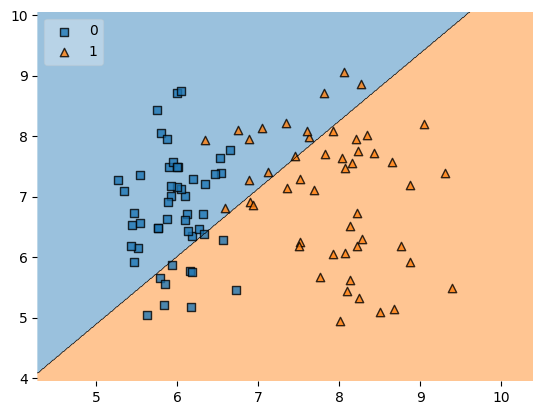

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.values,y.values,p, legend = 2)

# Lecture 5 -Coding the perceptron trick algorithm

In [ ]:
from sklearn.datasets import make_classification
import numpy as np
X,y = make_classification(n_samples = 100, n_features = 2, n_informative = 1, n_redundant=0,
                          n_classes = 2, n_clusters_per_class=1, random_state = 41, hypercube= False, class_sep = 10)

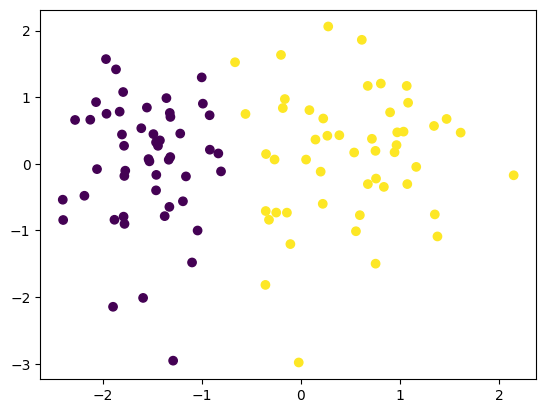

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y)

In [ ]:
def step(z):
  return 1 if z>0 else 0

In [ ]:
def perceptron(X,y):
  X = np.insert(X,0,1, axis = 1)
  weights = np.ones(X.shape[1])
  lr = 0.1

  for i in range(1000):
    j = np.random.randint(0,100)
    y_hat = step(np.dot(X[j], weights))
    weights = weights + lr*(y[j]-y_hat)*X[j]

  return weights[0], weights[1:]

In [ ]:

intercept_,coef_ = perceptron(X,y)

In [ ]:
coef_

array([1.35511512, 0.14268845])

In [ ]:
intercept_

np.float64(1.0)

In [ ]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [ ]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

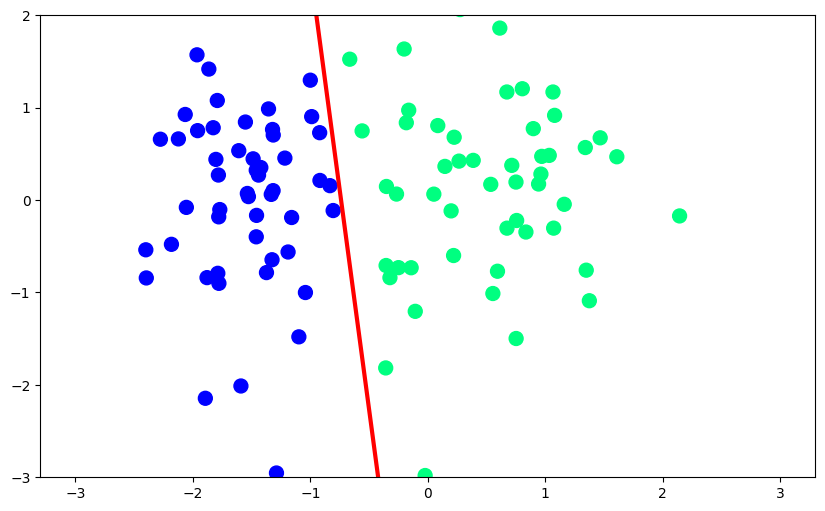

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

##Lec-6 Perceptron Loss Function

In [ ]:
from sklearn.datasets import make_classification
import numpy as np
X,y = make_classification(n_samples = 100, n_features = 2, n_informative = 1, n_redundant=0,
                          n_classes = 2, n_clusters_per_class=1, random_state = 41, hypercube= False, class_sep = 10)

In [ ]:
X.shape

(100, 2)

In [ ]:
y.shape

(100,)

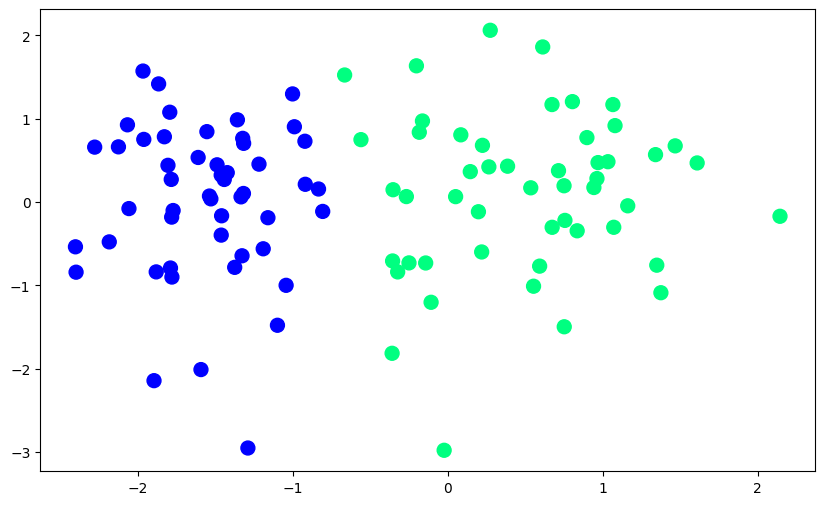

In [ ]:

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [ ]:
def perceptron(X,y):

    w1=w2=b=1
    lr = 0.1



    for i in range(X.shape[0]):
        for j in range(1000):
        # check condition
          z = w1*X[i][0] + w2*X[i][1] + b

          if z*y[i] < 0:
            w1 = w1 + lr*y[i]*X[i][0]
            w2 = w2 + lr*y[i]*X[i][1]
            b = b + lr*y[i]

    return w1,w2,b

In [ ]:
w1,w2,b = perceptron(X,y)

In [ ]:
m = -(w1/w2)
c = -(b/w2)

print(m,c)

-2.8833319733887324 -3.9038505967279806


(-3.0, 2.0)

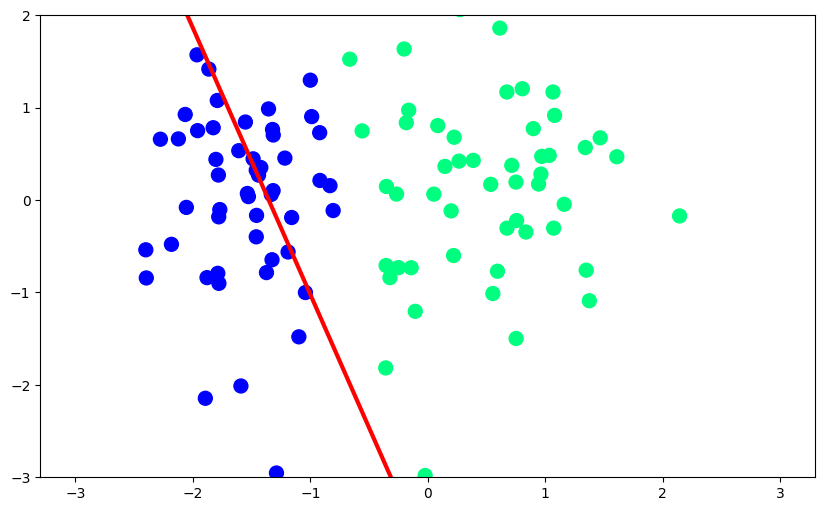

In [ ]:

x_input = np.linspace(-3,3,100)
y_input = m*x_input + c

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

##Lec-7 Problem with Perceptron

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
or_data = pd.DataFrame()
and_data = pd.DataFrame()
xor_data = pd.DataFrame()

In [3]:
or_data['input1']=[1,1,0,0]
or_data['input2']=[1,0,1,0]
or_data['ouput']=[1,1,1,0]

In [4]:
and_data['input1']=[1,1,0,0]
and_data['input2']=[1,0,1,0]
and_data['ouput']=[1,0,0,0]

In [5]:
xor_data['input1']=[1,1,0,0]
xor_data['input2']=[1,0,1,0]
xor_data['ouput']=[0,1,1,0]

<Axes: xlabel='input1', ylabel='input2'>

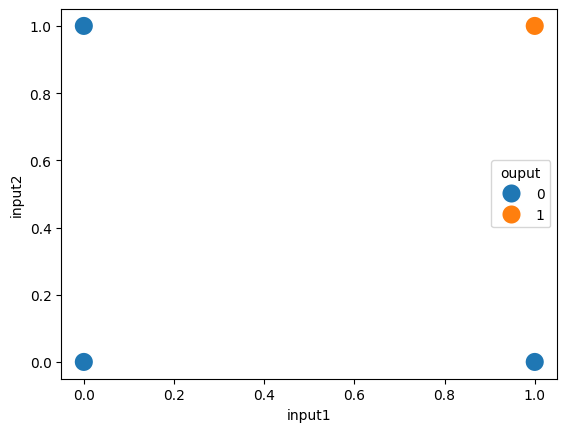

In [6]:
sns.scatterplot(x = and_data['input1'],y =and_data['input2'],hue=and_data['ouput'],s=200)

<Axes: xlabel='input1', ylabel='input2'>

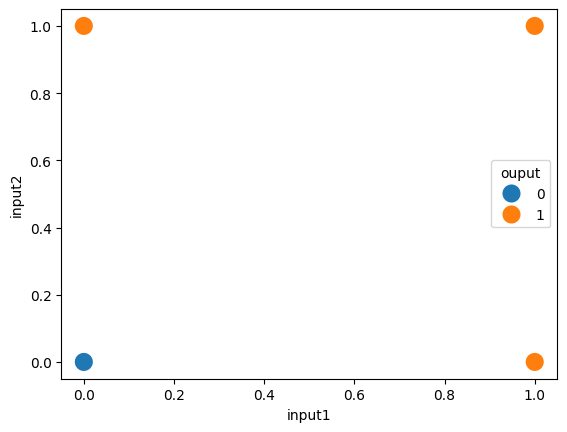

In [7]:
sns.scatterplot(x = or_data['input1'],y =or_data['input2'],hue=or_data['ouput'],s=200)

<Axes: xlabel='input1', ylabel='input2'>

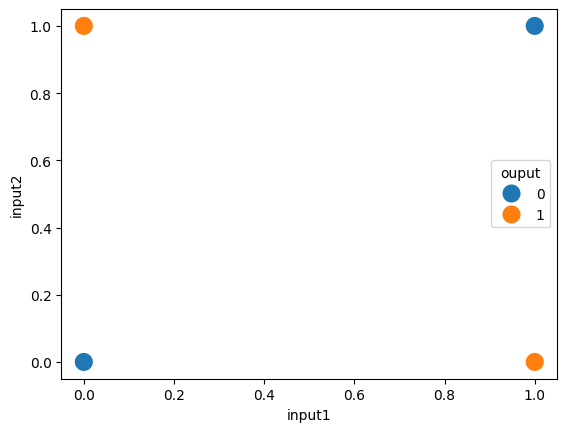

In [8]:
sns.scatterplot(x = xor_data['input1'],y =xor_data['input2'],hue=xor_data['ouput'],s=200)

In [9]:
from sklearn.linear_model import Perceptron
clf1=Perceptron()
clf2=Perceptron()
clf3=Perceptron()

In [10]:
clf1.fit(and_data.iloc[:,0:2].values,and_data.iloc[:,-1].values)
clf2.fit(or_data.iloc[:,0:2].values,or_data.iloc[:,-1].values)
clf3.fit(xor_data.iloc[:,0:2].values,xor_data.iloc[:,-1].values)

Perceptron()

In [11]:
clf1.coef_

array([[2., 2.]])

In [12]:
clf1.intercept_

array([-2.])

In [13]:
x=np.linspace(-1,1,5)
y=-x+1

<Axes: xlabel='input1', ylabel='input2'>

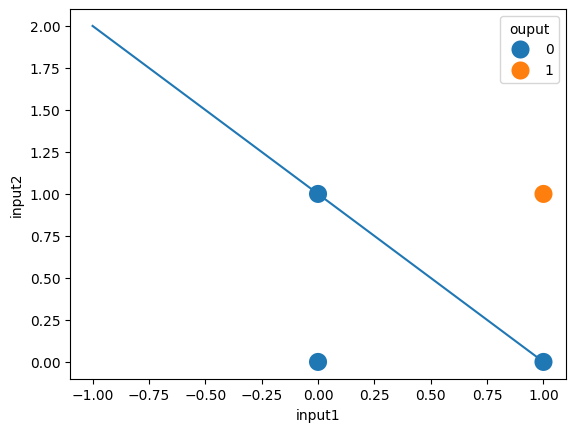

In [14]:
plt.plot(x,y)
sns.scatterplot(x = and_data['input1'],y =and_data['input2'],hue=and_data['ouput'],s=200)

In [15]:
clf2.coef_

array([[2., 2.]])

In [16]:
clf2.intercept_

array([-1.])

In [17]:
x1=np.linspace(-1,1,5)
y1=-x+0.5

<Axes: xlabel='input1', ylabel='input2'>

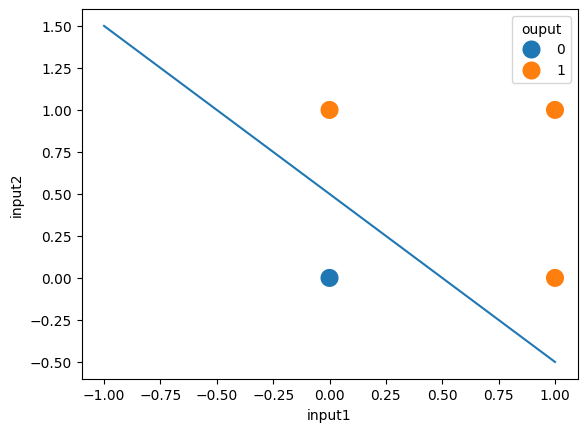

In [18]:
plt.plot(x1,y1)
sns.scatterplot(x = or_data['input1'],y =or_data['input2'],hue=or_data['ouput'],s=200)

In [19]:
clf3.coef_

array([[0., 0.]])

In [20]:
clf3.intercept_

array([0.])

In [21]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

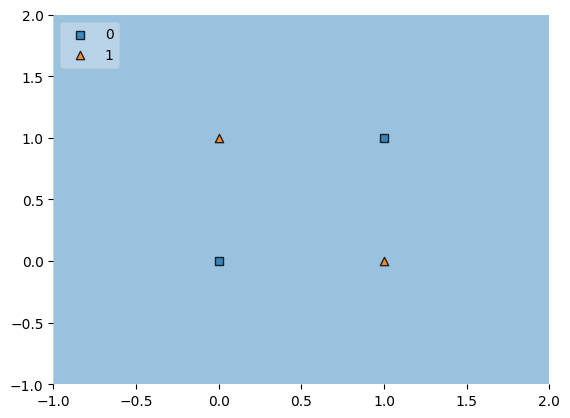

In [ ]:
plot_decision_regions(xor_data.iloc[:,0:2].values,xor_data.iloc[:,-1].values, clf=clf3, legend=2)